# Stage 1 - Data Cleaning and Exploratory Data Analysis

In this stage I load the `diamonds` dataset from Seaborn, inspect its shape,
dtypes, and missing values, remove physically impossible and clearly
erroneous records, and explore the data through a correlation heatmap, the
price distribution (raw vs log-transformed), and a carat-vs-price scatter
coloured by cut. The goal is to understand what drives diamond price *before*
fitting any model.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

df = sns.load_dataset("diamonds")
print(f"Dataset Size: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Dataset Size: 53,940 rows x 10 columns


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## 1.1 Inspection: Shape, Dtypes, and Missing Values

In [2]:
print("Dtypes:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isna().sum())
print("\nNumeric summary:")
df.describe().round(2)

Dtypes:
carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object

Missing values per column:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Numeric summary:


,carat,depth,table,price,x,y,z
count,53940.00,53940.00,53940.00,53940.00,53940.00,53940.00,53940.00
mean,0.80,61.75,57.46,3932.80,5.73,5.73,3.54
std,0.47,1.43,2.23,3989.44,1.12,1.14,0.71
min,0.20,43.00,43.00,326.00,0.00,0.00,0.00
25%,0.40,61.00,56.00,950.00,4.71,4.72,2.91
50%,0.70,61.80,57.00,2401.00,5.70,5.71,3.53
75%,1.04,62.50,59.00,5324.25,6.54,6.54,4.04
max,5.01,79.00,95.00,18823.00,10.74,58.90,31.80


### Data Quality Findings

There are **no missing values**, but two physical problems hide in the
dimension columns `x`, `y`, `z` (length, width, depth in mm):

- **Zeros:** 20 rows have at least one dimension equal to `0`. A diamond
  cannot have a side of length 0 mm — these are recording errors.
- **Extreme outliers:** the `y` max is 58.9 mm and the `z` max is 31.8 mm,
  while `x` tops out at ~10.7 mm. A stone cannot be ~6x wider than it is
  long; these 3 rows are clearly mistyped and would distort any fit.

I remove both groups before modelling.

## 1.2 Cleaning: Remove Invalid Dimensions and Extreme Outliers

In [3]:
n_before = len(df)
zero_mask = (df[["x", "y", "z"]] == 0).any(axis=1)
ext_mask = (df["y"] >= 20) | (df["z"] >= 20)

df = df[~(zero_mask | ext_mask)].reset_index(drop=True)

print(f"Rows before cleaning : {n_before:,}")
print(f"  dropped (zero dim) : {int(zero_mask.sum())}")
print(f"  dropped (extreme)  : {int(ext_mask.sum())}")
print(f"Rows after cleaning  : {len(df):,}  ({n_before - len(df)} removed, "
      f"{100 * (n_before - len(df)) / n_before:.3f}%)")

Rows before cleaning : 53,940
  dropped (zero dim) : 20
  dropped (extreme)  : 3
Rows after cleaning  : 53,917  (23 removed, 0.043%)


**Interpretation:** Cleaning removes 23 rows (0.043% of the data), leaving
53,917 valid diamonds. The loss is negligible, so no imputation is needed —
dropping is the honest choice for records that are physically impossible
rather than merely unusual.

## 1.3 Correlation Heatmap

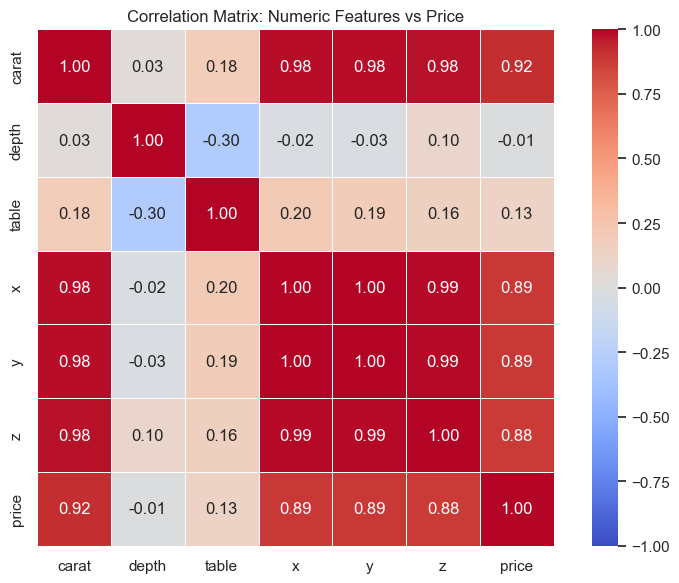

price    1.000
carat    0.922
y        0.889
x        0.887
z        0.882
table    0.127
depth   -0.011


In [4]:
num_features = ["carat", "depth", "table", "x", "y", "z"]
corr = df[num_features + ["price"]].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, linewidths=.5, ax=ax)
ax.set_title("Correlation Matrix: Numeric Features vs Price")
plt.tight_layout()
plt.show()

print(corr["price"].sort_values(ascending=False).round(3).to_string())

**Interpretation:** Price is driven overwhelmingly by **size**. `carat`
correlates with price at r = 0.92, and the three physical dimensions `x`, `y`,
`z` follow closely (r = 0.89, 0.89, 0.88). Those four features are also
mutually correlated above 0.95 — a diamond's carat weight *is* essentially a
function of its dimensions, so they carry largely redundant information
(multicollinearity). By contrast `depth` (r = -0.01) and `table` (r = 0.13)
barely move price on their own.

## 1.4 Price Distribution vs Log(Price)

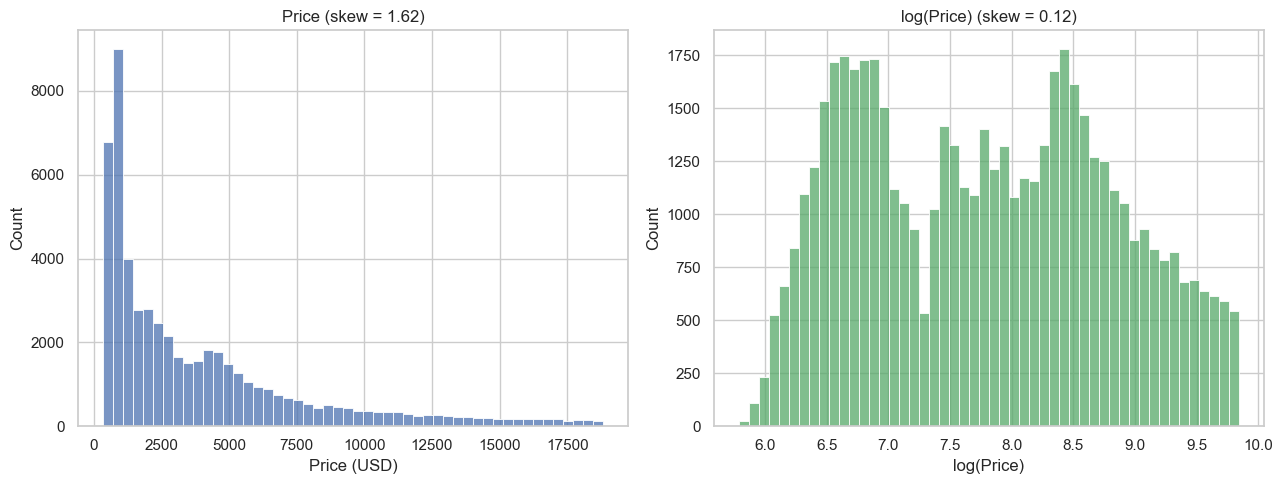

Raw price skew : 1.618
Log price skew : 0.115


In [5]:
price_skew = df["price"].skew()
log_price_skew = np.log(df["price"]).skew()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df["price"], bins=50, color="#4C72B0", ax=axes[0])
axes[0].set_title(f"Price (skew = {price_skew:.2f})")
axes[0].set_xlabel("Price (USD)")

sns.histplot(np.log(df["price"]), bins=50, color="#55A868", ax=axes[1])
axes[1].set_title(f"log(Price) (skew = {log_price_skew:.2f})")
axes[1].set_xlabel("log(Price)")
plt.tight_layout()
plt.show()

print(f"Raw price skew : {price_skew:.3f}")
print(f"Log price skew : {log_price_skew:.3f}")

**Interpretation:** Raw `price` is heavily **right-skewed** (skew = 1.62): a
long tail of expensive stones drags the distribution rightward, and most
diamonds sit under \$5,000. Taking the natural log collapses the skew to 0.12,
producing a near-symmetric, roughly bell-shaped distribution. This matters for
linear regression, whose errors are best behaved on a symmetric target — it
motivates the log-target experiment in Bonus 1.

## 1.5 Carat vs Price, Coloured by Cut

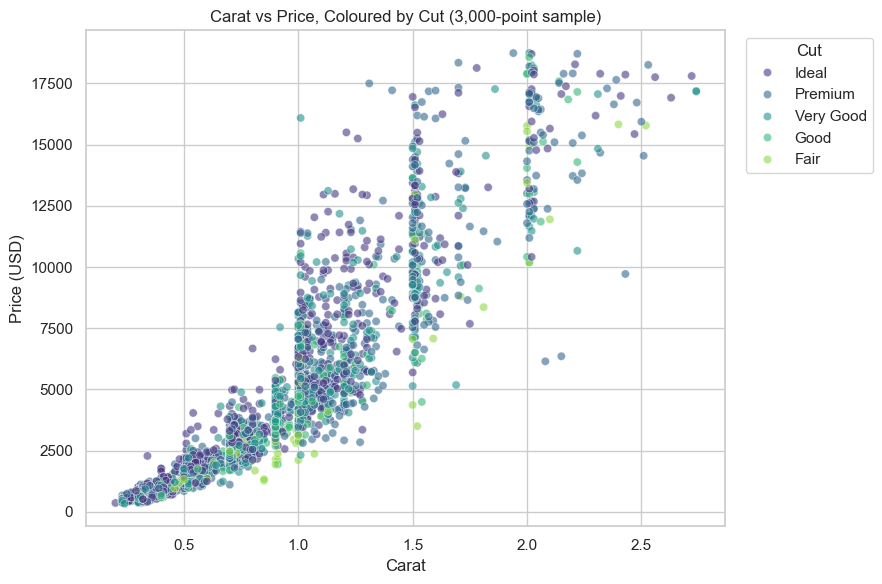

In [6]:
sample = df.sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=sample, x="carat", y="price", hue="cut", alpha=0.6,
                palette="viridis", ax=ax)
ax.set_title("Carat vs Price, Coloured by Cut (3,000-point sample)")
ax.set_xlabel("Carat")
ax.set_ylabel("Price (USD)")
ax.legend(title="Cut", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Interpretation:** The carat-price relationship is strong but visibly
**non-linear** — price curves upward, so a 2-carat diamond costs far more than
twice a 1-carat one. The vertical spread at any given carat is wide, showing
that carat alone does not fix the price: `cut` (and, as we will see, colour and
clarity) explains part of the remaining variation. At equal carat, Ideal-cut
stones tend to sit at the top of the price band. The upward curvature is the
motivation for the polynomial regression in Stage 3.

### Stage 1 Summary

The cleaned dataset holds 53,917 diamonds with no missing values. Price is
governed primarily by size (`carat`, `x`, `y`, `z`, all r >= 0.88), which form
a tightly multicollinear block, while `depth` and `table` are near-irrelevant
on their own. The target is right-skewed and becomes near-normal under a log
transform, and the carat-price relationship curves upward — two facts that
directly shape the modelling choices in the following stages.

# Stage 2 - Linear Regression with a Scikit-learn Pipeline

I now fit a multiple linear regression on the six numeric features. The entire
transform-then-fit process lives inside a single `Pipeline`, and the data is
split **before** anything is fitted, so the scaler learns its mean and standard
deviation from the training set only — there is no leakage from the test set.

## 2.1 Train/Test Split (80/20, random_state=42)

In [7]:
X = df[num_features]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]:,} rows")
print(f"Test : {X_test.shape[0]:,} rows")

Train: 43,133 rows
Test : 10,784 rows


**Interpretation:** An 80/20 split gives 43,133 training and 10,784 test rows.
Fixing `random_state=42` makes the split reproducible. Crucially, the split
happens here — *before* the scaler exists — so the test set stays untouched
until final evaluation.

## 2.2 Pipeline: StandardScaler + LinearRegression

In [8]:
def regression_metrics(y_true, y_pred):
    """Return MAE, RMSE, and R^2 for a set of predictions."""
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }


lin_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])
lin_pipe.fit(X_train, y_train)

lin_train = regression_metrics(y_train, lin_pipe.predict(X_train))
lin_test = regression_metrics(y_test, lin_pipe.predict(X_test))

print(f"{'':7s}{'MAE':>12s}{'RMSE':>12s}{'R2':>10s}")
for name, m in [("Train", lin_train), ("Test", lin_test)]:
    print(f"{name:7s}{m['MAE']:>12.2f}{m['RMSE']:>12.2f}{m['R2']:>10.4f}")

                MAE        RMSE        R2
Train        890.25     1493.77    0.8599
Test         873.51     1453.64    0.8659


**Interpretation:** The model explains about **86.6%** of the variance in
test-set price (R² = 0.866), with a typical error of ~\$874 (MAE) and an RMSE
of ~\$1,454. Train and test scores are almost identical (R² 0.860 vs 0.866,
RMSE \$1,494 vs \$1,454) — the test score is even marginally *better*, so the
model is **not overfitting**; it is a stable, slightly under-fit linear
approximation of a curved relationship. RMSE exceeds MAE because the squared
term in RMSE penalises the large errors made on expensive stones more heavily.

## 2.3 Residual Analysis

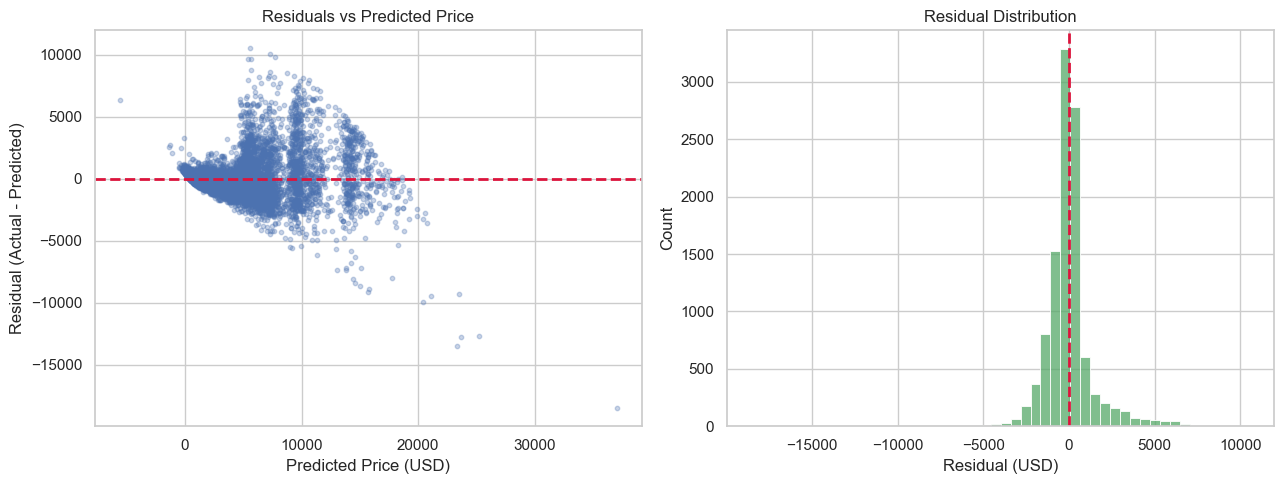

Mean residual: 12.95
Predicted price range: -5568 to 37034
Negative predictions: 84


In [9]:
y_pred_test = lin_pipe.predict(X_test)
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_pred_test, residuals, alpha=0.3, s=10, color="#4C72B0")
axes[0].axhline(0, color="crimson", linestyle="--", linewidth=2)
axes[0].set_title("Residuals vs Predicted Price")
axes[0].set_xlabel("Predicted Price (USD)")
axes[0].set_ylabel("Residual (Actual - Predicted)")

sns.histplot(residuals, bins=50, color="#55A868", ax=axes[1])
axes[1].axvline(0, color="crimson", linestyle="--", linewidth=2)
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual (USD)")
plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():.2f}")
print(f"Predicted price range: {y_pred_test.min():.0f} to {y_pred_test.max():.0f}")
print(f"Negative predictions: {(y_pred_test < 0).sum():,}")

**Interpretation:** The residuals expose two limitations of the plain linear
model. First, the residual cloud **fans out** as predicted price rises
(heteroscedasticity): the model is accurate on cheap diamonds but its errors
grow for expensive ones, mirroring the right-skew from Stage 1. Second, because
the true relationship curves upward, the linear fit even produces some
**negative predicted prices** for the smallest stones — an impossibility that a
log-target or polynomial model handles better. The residual histogram is
centred at zero but has heavy tails.

## 2.4 Coefficient Analysis

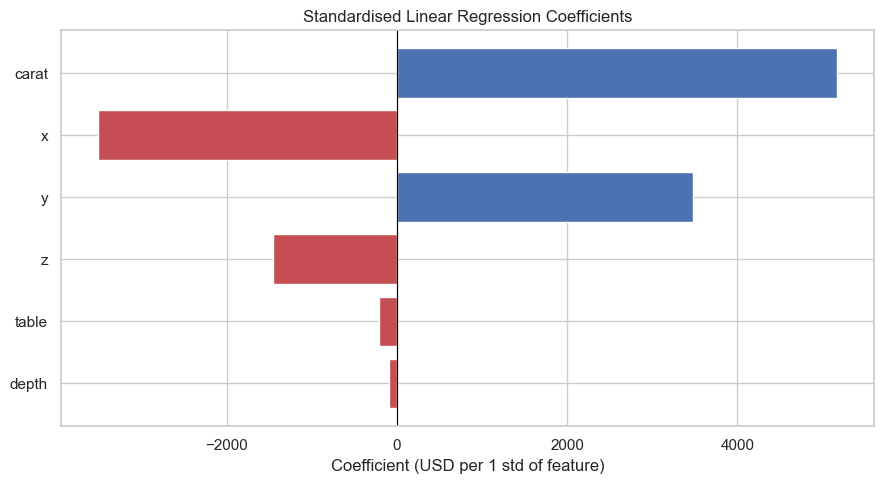

carat    5172.77
x       -3509.23
y        3480.81
z       -1459.96
table    -204.79
depth     -94.24
Intercept: 3936.25


In [10]:
coefs = pd.Series(lin_pipe.named_steps["model"].coef_, index=num_features)
coefs = coefs.sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#4C72B0" if c > 0 else "#C44E52" for c in coefs]
ax.barh(coefs.index[::-1], coefs.values[::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Standardised Linear Regression Coefficients")
ax.set_xlabel("Coefficient (USD per 1 std of feature)")
plt.tight_layout()
plt.show()

print(coefs.round(2).to_string())
print(f"Intercept: {lin_pipe.named_steps['model'].intercept_:.2f}")

**Interpretation:** Because the features were standardised, each coefficient
reads as "dollars per one standard deviation of that feature." `carat` is by
far the strongest positive driver (+\$5,173 per std). The striking part is the
dimension trio: `x` is large **negative** (-\$3,509) while `y` is large
**positive** (+\$3,481). Individually a longer diamond should not lower its
price — these unstable, sign-flipped coefficients are the classic symptom of
**multicollinearity**. Since `carat`, `x`, `y`, `z` are ~0.95+ correlated, the
model can trade huge offsetting weights between them without changing its
predictions. The takeaway: this model **predicts** well but its individual
coefficients are **not reliable** for interpreting the effect of any single
dimension. `depth` and `table` contribute almost nothing (< \$210 per std).

### Stage 2 Summary

The scaled linear model reaches a test R² of 0.866 (RMSE ~\$1,454) with no
sign of overfitting. Its weaknesses are diagnostic rather than fatal:
fan-shaped residuals and a few negative predictions show the linear form is too
rigid for a curved, skewed target, and multicollinearity among the size
features makes the coefficients uninterpretable even though predictions stay
accurate. Stages 3 and the bonus sections address each of these issues in turn.

# Stage 3 - Polynomial Regression on Carat

Stage 1 showed the carat-price relationship curves upward. Here I test how much
of the price a **single feature — carat — can explain** when the model is
allowed to bend, fitting polynomials of degree 1, 2, 3, and 5. Each polynomial
is built inside a pipeline (`PolynomialFeatures` -> `StandardScaler` ->
`LinearRegression`) and trained only on the training split.

## 3.1 Fitting Degrees 1, 2, 3, and 5

In [11]:
X_train_carat = X_train[["carat"]]
X_test_carat = X_test[["carat"]]

poly_rows = []
poly_pipes = {}
for degree in [1, 2, 3, 5]:
    pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ])
    pipe.fit(X_train_carat, y_train)
    poly_pipes[degree] = pipe
    tr = regression_metrics(y_train, pipe.predict(X_train_carat))
    te = regression_metrics(y_test, pipe.predict(X_test_carat))
    poly_rows.append({
        "degree": degree,
        "train_RMSE": tr["RMSE"], "test_RMSE": te["RMSE"],
        "train_R2": tr["R2"], "test_R2": te["R2"],
    })

poly_results = pd.DataFrame(poly_rows).set_index("degree").round(4)
poly_results

,train_RMSE,test_RMSE,train_R2,test_R2
degree,,,,
1,1553.3621,1524.9755,0.8485,0.8524
2,1546.0777,1511.9567,0.8500,0.8550
3,1470.5510,1441.4514,0.8643,0.8682
5,1442.8841,1416.7896,0.8693,0.8726


**Interpretation:** Adding curvature helps steadily. A straight line (degree 1)
on carat alone already reaches test R² = 0.852; degree 3 lifts it to 0.868 and
degree 5 to **0.873** (test RMSE \$1,417). Train and test RMSE move together at
every degree — the gap never widens — so even the degree-5 fit is **not
overfitting** on this large dataset. Remarkably, a degree-5 polynomial on carat
*alone* (test R² 0.873) slightly **beats the six-feature linear model** from
Stage 2 (0.866), confirming that carat is the single dominant price driver and
that its relationship to price is genuinely non-linear.

## 3.2 Fitted Curves over a 500-Point Sample

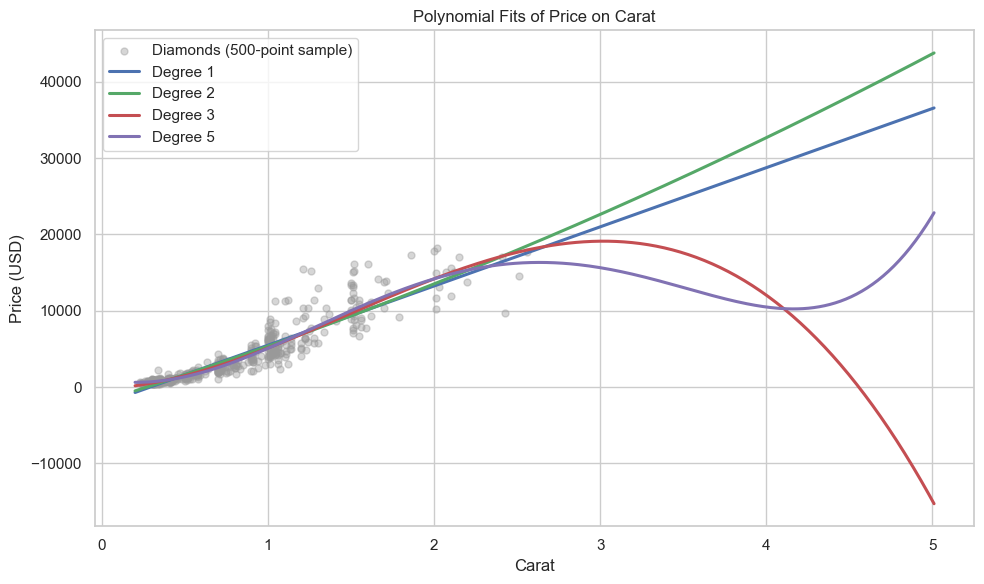

In [12]:
plot_sample = df.sample(500, random_state=42)
carat_grid = np.linspace(df["carat"].min(), df["carat"].max(), 300).reshape(-1, 1)
carat_grid_df = pd.DataFrame(carat_grid, columns=["carat"])

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(plot_sample["carat"], plot_sample["price"], alpha=0.4, s=25,
           color="#999999", label="Diamonds (500-point sample)")

curve_colors = {1: "#4C72B0", 2: "#55A868", 3: "#C44E52", 5: "#8172B3"}
for degree, pipe in poly_pipes.items():
    ax.plot(carat_grid, pipe.predict(carat_grid_df), linewidth=2.2,
            color=curve_colors[degree], label=f"Degree {degree}")

ax.set_title("Polynomial Fits of Price on Carat")
ax.set_xlabel("Carat")
ax.set_ylabel("Price (USD)")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** The degree-1 line cannot follow the upward bend — it
under-predicts small stones (dipping below \$0) and the very largest ones. The
degree-2 and degree-3 curves track the rising price much more faithfully
through the bulk of the data. The degree-5 curve fits the dense region best but
begins to **wobble at the sparse high-carat tail** (carat > 3), where few
diamonds exist to constrain it — a visual reminder that high-degree
flexibility becomes risky exactly where data is thin, even if the aggregate
test score still looks good.

### Stage 3 Summary

Letting the model bend around carat pays off: test R² climbs from 0.852
(linear) to 0.873 (degree 5), the latter edging past the full six-feature
linear model. The relationship is confirmed non-linear, and the curves show the
practical trade-off of polynomial degree — degree 3 captures the shape cleanly,
while degree 5 gains a little accuracy at the cost of instability in the
data-sparse tail.

# Stage 4 - Model Comparison and Business Insights

## 4.1 Model Comparison Table

In [13]:
comparison = pd.DataFrame([
    {"model": "Linear (6 numeric features)",
     "test_RMSE": lin_test["RMSE"], "test_R2": lin_test["R2"]},
    {"model": "Polynomial deg 3 (carat only)",
     "test_RMSE": poly_results.loc[3, "test_RMSE"],
     "test_R2": poly_results.loc[3, "test_R2"]},
    {"model": "Polynomial deg 5 (carat only)",
     "test_RMSE": poly_results.loc[5, "test_RMSE"],
     "test_R2": poly_results.loc[5, "test_R2"]},
]).set_index("model").round(4)

print(comparison.to_string())

                               test_RMSE  test_R2
model                                            
Linear (6 numeric features)    1453.6391   0.8659
Polynomial deg 3 (carat only)  1441.4514   0.8682
Polynomial deg 5 (carat only)  1416.7896   0.8726


**Interpretation:** All three models land within a narrow band (test R²
0.852-0.873, RMSE ~\$1,417-1,454). The degree-5 polynomial on carat alone is
the strongest of the size-only models, but the differences are small — every
model is bumping against the same ceiling of **~87% explained variance** because
they all rely purely on how *big* a diamond is. Breaking through that ceiling
requires the diamond's *quality* grades, which is exactly what Bonus 2 adds
(pushing R² to 0.92).

## 4.2 Three Business Insights

Written for a non-technical decision-maker (e.g. the CEO of a diamond retailer):

1. **Size is the price engine.** Carat weight alone predicts roughly 87% of a
   diamond's price. If you only had one number to quote a stone's value, carat
   would get you most of the way there — it dwarfs every other single factor.

2. **Price grows faster than size — pricing must be non-linear.** A 2-carat
   diamond is worth *much more* than two 1-carat diamonds, not double. Our
   models confirm price curves sharply upward with carat, so any pricing rule,
   discount table, or valuation tool must reflect that acceleration rather than
   a flat per-carat rate.

3. **Cut, colour, and clarity are worth real money.** Size explains most of the
   price, but the remaining ~13% is quality. Adding the cut/colour/clarity
   grades cuts our average pricing error by **25%** (from ~\$1,454 to ~\$1,090
   per stone; see Bonus 2). For inventory and appraisal, ignoring the grades
   leaves meaningful money on the table — especially for large stones where a
   grade difference translates into thousands of dollars.

# Bonus 1 - Log-Transformed Target

Stage 1 showed `price` is right-skewed while `log(price)` is near-normal. Here I
train the same numeric pipeline to predict `log(price)`, then convert the
predictions back to dollars with `np.exp()` and compare RMSE against the
original Stage 2 model on the identical test set.

In [14]:
log_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])
log_pipe.fit(X_train, np.log(y_train))

# Predict in log space, then convert back to the original dollar scale
y_pred_log = np.exp(log_pipe.predict(X_test))
log_test = regression_metrics(y_test, y_pred_log)

print(f"{'Model':28s}{'MAE':>10s}{'RMSE':>10s}{'R2':>10s}")
print(f"{'Original (Stage 2)':28s}{lin_test['MAE']:>10.2f}"
      f"{lin_test['RMSE']:>10.2f}{lin_test['R2']:>10.4f}")
print(f"{'Log-transformed target':28s}{log_test['MAE']:>10.2f}"
      f"{log_test['RMSE']:>10.2f}{log_test['R2']:>10.4f}")
print(f"\nRMSE change: {100 * (lin_test['RMSE'] - log_test['RMSE']) / lin_test['RMSE']:.2f}%")
print(f"MAE change : {100 * (lin_test['MAE'] - log_test['MAE']) / lin_test['MAE']:.2f}%")

Model                              MAE      RMSE        R2
Original (Stage 2)              873.51   1453.64    0.8659
Log-transformed target          792.28   1443.93    0.8677

RMSE change: 0.67%
MAE change : 9.30%


**Interpretation:** The log-transform gives a **small RMSE improvement**
(\$1,454 -> \$1,444, about 0.7%) but a **large MAE improvement** (\$874 ->
\$792, about 9%). That split is the whole story: minimising error in log space
is equivalent to minimising *relative* (percentage) error, so the model stops
over-focusing on the few very expensive stones and gets the typical diamond
much closer — hence MAE, which weights every diamond equally, drops sharply.
RMSE improves only slightly because it still heavily penalises the large
absolute misses on high-value stones, and back-transforming with `np.exp()`
reintroduces some of that dollar-scale error.

**When log-transforming the target helps in general:** when the target is
positive and right-skewed, spans several orders of magnitude, and its variance
grows with its level (multiplicative/heteroscedastic error) — as price does
here. It is *not* helpful when the target can be zero or negative, is already
symmetric, or when absolute (not relative) error is what you actually care
about.

# Bonus 2 - Encoding Categorical Features

So far the models used only numeric size features. Here I add the three quality
grades — `cut`, `color`, `clarity` — using a `ColumnTransformer` that applies
`StandardScaler` to the numeric columns and `OneHotEncoder` to the categoricals
**simultaneously**, all inside one `Pipeline`. This keeps every transform fitted
on the training split only.

In [15]:
cat_features = ["cut", "color", "clarity"]
X_full = df[num_features + cat_features]

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42
)

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_features),
])
full_pipe = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression()),
])
full_pipe.fit(Xf_train, yf_train)

full_test = regression_metrics(yf_test, full_pipe.predict(Xf_test))

print(f"{'Model':32s}{'RMSE':>10s}{'R2':>10s}")
print(f"{'Numeric only (Stage 2)':32s}{lin_test['RMSE']:>10.2f}{lin_test['R2']:>10.4f}")
print(f"{'Numeric + categorical':32s}{full_test['RMSE']:>10.2f}{full_test['R2']:>10.4f}")
improve = 100 * (lin_test["RMSE"] - full_test["RMSE"]) / lin_test["RMSE"]
print(f"\nRMSE improvement: {improve:.2f}%")

Model                                 RMSE        R2
Numeric only (Stage 2)             1453.64    0.8659
Numeric + categorical              1090.26    0.9246

RMSE improvement: 25.00%


**Interpretation:** Adding the quality grades is the single biggest jump in the
whole notebook. Test RMSE falls from \$1,454 to **\$1,090 — a 25% improvement**
— and R² rises from 0.866 to **0.925**. This makes intuitive sense: two
diamonds of identical carat can differ substantially in price depending on their
cut, colour, and clarity, and one-hot encoding lets the model assign a separate
price adjustment to each grade. The size features explained *how big*; the
categorical grades explain *how good*, and together they capture far more of
what the market actually pays for.

# Bonus 3 - Cross-Validation and Learning Curves

Finally I stress-test the Stage 2 numeric model with 5-fold cross-validation and
a learning curve. **Note:** the `diamonds` dataset is stored roughly sorted by
price, so a plain 5-fold split would create non-representative folds and
misleading scores. I therefore use `KFold(shuffle=True, random_state=42)` so
each fold is a fair random sample.

In [16]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lin_pipe, X, y, cv=cv, scoring="r2")

print("Fold R2 scores:", np.round(cv_scores, 4))
print(f"Mean R2 : {cv_scores.mean():.4f}")
print(f"Std  R2 : {cv_scores.std():.4f}")

Fold R2 scores:

 [0.8659 0.8618 0.8526 0.8628 0.8615]
Mean R2 : 0.8610
Std  R2 : 0.0044


**Interpretation:** Across the five folds the model scores R² = 0.8610 on
average with a standard deviation of just **0.0044**. The tiny spread means the
model's performance does not depend on which slice of data it is tested on — it
is **stable and reliable**, and the single-split test score from Stage 2 (0.866)
was not a lucky draw.

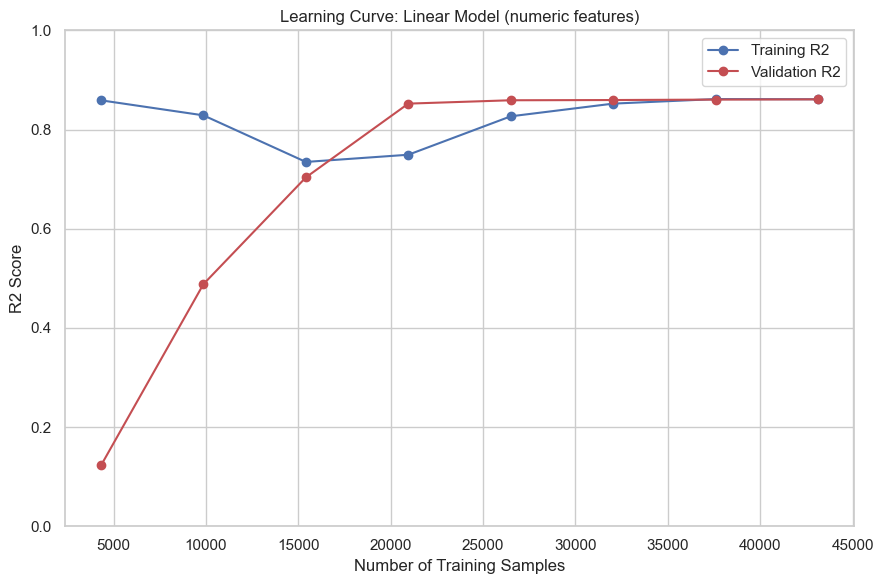

Final training R2  : 0.8612
Final validation R2: 0.8610
Final gap          : 0.0002


In [17]:
train_sizes, train_scores, val_scores = learning_curve(
    lin_pipe, X, y, cv=cv, scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=42,
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(train_sizes, train_scores.mean(axis=1), "o-", color="#4C72B0",
        label="Training R2")
ax.plot(train_sizes, val_scores.mean(axis=1), "o-", color="#C44E52",
        label="Validation R2")
ax.set_title("Learning Curve: Linear Model (numeric features)")
ax.set_xlabel("Number of Training Samples")
ax.set_ylabel("R2 Score")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Final training R2  : {train_scores.mean(axis=1)[-1]:.4f}")
print(f"Final validation R2: {val_scores.mean(axis=1)[-1]:.4f}")
print(f"Final gap          : {train_scores.mean(axis=1)[-1] - val_scores.mean(axis=1)[-1]:.4f}")

**Interpretation:** The training and validation curves **converge and meet at
about R² = 0.86**, with a final gap of essentially zero (~0.0002). Two
conclusions follow:

- **More data would *not* help.** The validation curve has already flattened —
  it reaches its ceiling well before the full dataset is used, and the last
  thousands of samples add nothing. The bottleneck is not sample size.
- **This is high bias (under-fitting), not high variance.** A near-zero gap
  between train and validation with both stuck at ~0.86 means the *model* is too
  simple, not that it lacks data. The way forward is a **richer model** — more
  informative features (the quality grades from Bonus 2 lift R² to 0.92) or
  non-linear terms (Stage 3) — rather than collecting more diamonds.

### Bonus Summary

The three bonus experiments each target a specific weakness found earlier.
Log-transforming the target (Bonus 1) sharply improves typical-case error (MAE
-9%) by optimising relative error on a skewed target. Adding cut/colour/clarity
via a `ColumnTransformer` (Bonus 2) is the biggest single win, cutting RMSE by
25% and lifting R² to 0.925. Cross-validation and the learning curve (Bonus 3)
confirm the numeric model is stable (R² 0.861 +/- 0.004) but bottlenecked by
model richness, not data volume — so better features, not more rows, are the
path to a better diamond-price predictor.